# HOMEWORK 1

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt


In [5]:

# ============================================================
# Load dataset
# ============================================================

DATA_PATH = "FuelEconomy.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

print("\nSummary statistics:")
display(df.describe(include="all"))

print("\nMissing values per column:")
display(df.isna().sum())


Shape: (100, 2)

Columns:
['Horse Power', 'Fuel Economy (MPG)']


,Horse Power,Fuel Economy (MPG)
0,118.770799,29.344195
1,176.326567,24.695934
2,219.262465,23.952010
3,187.310009,23.384546
4,218.594340,23.426739



Summary statistics:


,Horse Power,Fuel Economy (MPG)
count,100.000000,100.000000
mean,213.676190,23.178501
std,62.061726,4.701666
min,50.000000,10.000000
25%,174.996514,20.439516
50%,218.928402,23.143192
75%,251.706476,26.089933
max,350.000000,35.000000



Missing values per column:


Horse Power           0
Fuel Economy (MPG)    0
dtype: int64

Based on the summary statistics: there are no missing values in the dataset.

In [6]:
# Define some helper functions for ML
TARGET_COL = "Horse Power"

# Split the data into 70/30 sets
def split_data(X, y, test_size, random_state):
    """70/30 random train-test split."""
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

# Calculate the metrics for evaluation
def compute_metrics(y_true, y_pred):
    """Return MSE, MAE, R^2."""
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R^2": r2_score(y_true, y_pred),
    }

# Prepare the dataset for training
def prepare_xy(df_in, target_col=TARGET_COL):
    """Drop missing rows, split into X and y."""
    df_clean = df_in.dropna().copy()
    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col]
    return X, y

def print_fitted_equation(model, input_feature_names, target_name=TARGET_COL, top_k_terms=15):
    """Print a readable fitted equation.

    For polynomial models, the number of terms can become very large,
    so we print only the TOP-K terms by absolute coefficient magnitude.
    """
    intercept, coefs, feat_names = _get_linear_parts(model, input_feature_names)

    # Sort by absolute coefficient magnitude
    order = np.argsort(np.abs(coefs))[::-1]
    order = order[:min(top_k_terms, len(coefs))]

    terms = []
    for idx in order:
        terms.append(f"({coefs[idx]:+.4f}) * {feat_names[idx]}")

    eq = f"{target_name} = {intercept:.4f} " + " ".join(terms)

    print("\n--- Fitted Model Equation (Top Terms) ---")
    print(eq)
    if len(coefs) > top_k_terms:
        print(f"(Showing top {top_k_terms} terms out of {len(coefs)} total terms.)")


def _get_linear_parts(model, input_feature_names):
    """Extract (intercept, coefficients, feature_names) from either:
       - LinearRegression
       - Pipeline(PolynomialFeatures -> LinearRegression)
    """
    # Plain LinearRegression
    if isinstance(model, LinearRegression):
        intercept = float(model.intercept_)
        coefs = np.array(model.coef_).ravel()
        feat_names = np.array(list(input_feature_names))
        return intercept, coefs, feat_names

    # Polynomial pipeline
    if hasattr(model, "named_steps") and "poly" in model.named_steps and "lr" in model.named_steps:
        poly = model.named_steps["poly"]
        lr = model.named_steps["lr"]

        feat_names = poly.get_feature_names_out(input_features=list(input_feature_names))
        intercept = float(lr.intercept_)
        coefs = np.array(lr.coef_).ravel()
        return intercept, coefs, np.array(feat_names)

    raise ValueError("Unsupported model type for equation printing.")




def run_models_and_evaluate(df_in, scenario_name, degrees=(1, 2, 3, 4),
                            target_col=TARGET_COL, test_size=0.30, random_state=42,
                            show_equation=True, top_k_terms=15):
    """Train/evaluate linear (deg=1) + polynomial regression models.

    Returns a DataFrame of metrics.
    Also prints fitted equations and scatter plots (test set) for each model.
    """
    X, y = prepare_xy(df_in, target_col=target_col)
    X_train, X_test, y_train, y_test = split_data(X, y, test_size=test_size, random_state=random_state)

    rows = []

    for deg in degrees:
        if deg == 1:
            model = LinearRegression()
            model_name = "Linear Regression"
        else:
            model = Pipeline([
                ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
                ("lr", LinearRegression())
            ])
            model_name = f"Polynomial Regression (degree={deg})"

        # Fit model
        model.fit(X_train, y_train)

        # Predict
        yhat_train = model.predict(X_train)
        yhat_test  = model.predict(X_test)

        # Metrics
        train_m = compute_metrics(y_train, yhat_train)
        test_m  = compute_metrics(y_test, yhat_test)

        # Report equation + plot (TEST set)
        print("\n============================================================")
        print(f"Scenario: {scenario_name}")
        print(f"Model: {model_name}")
        print("============================================================")

        if show_equation:
            print_fitted_equation(
                model=model,
                input_feature_names=X_train.columns,
                target_name=target_col,
                top_k_terms=top_k_terms
            )


        rows.append({
            "Scenario": scenario_name,
            "Model": model_name,
            "Train MSE": train_m["MSE"],
            "Train MAE": train_m["MAE"],
            "Train R^2": train_m["R^2"],
            "Test MSE": test_m["MSE"],
            "Test MAE": test_m["MAE"],
            "Test R^2": test_m["R^2"],
            "Train size": len(X_train),
            "Test size": len(X_test),
        })

    return pd.DataFrame(rows)


In [7]:
results_A = run_models_and_evaluate(
    df,
    scenario_name="Regression Model Prediction",
    degrees=(1, 2, 3, 4),
    show_equation=True,
    top_k_terms=15
)

display(results_A)


Scenario: Regression Model Prediction
Model: Linear Regression

--- Fitted Model Equation (Top Terms) ---
Horse Power = 500.3638 (-12.3785) * Fuel Economy (MPG)

Scenario: Regression Model Prediction
Model: Polynomial Regression (degree=2)

--- Fitted Model Equation (Top Terms) ---
Horse Power = 457.3741 (-8.5915) * Fuel Economy (MPG) (-0.0800) * Fuel Economy (MPG)^2

Scenario: Regression Model Prediction
Model: Polynomial Regression (degree=3)

--- Fitted Model Equation (Top Terms) ---
Horse Power = 355.6514 (+6.0952) * Fuel Economy (MPG) (-0.7505) * Fuel Economy (MPG)^2 (+0.0097) * Fuel Economy (MPG)^3

Scenario: Regression Model Prediction
Model: Polynomial Regression (degree=4)

--- Fitted Model Equation (Top Terms) ---
Horse Power = 90.1049 (+61.1736) * Fuel Economy (MPG) (-4.7743) * Fuel Economy (MPG)^2 (+0.1339) * Fuel Economy (MPG)^3 (-0.0014) * Fuel Economy (MPG)^4


,Scenario,Model,Train MSE,Train MAE,Train R^2,Test MSE,Test MAE,Test R^2,Train size,Test size
0,Regression Model Prediction,Linear Regression,357.699180,16.061689,0.906320,318.561087,14.940628,0.912561,70,30
1,Regression Model Prediction,Polynomial Regression (degree=2),350.879731,15.995824,0.908106,331.105434,15.148330,0.909118,70,30
2,Regression Model Prediction,Polynomial Regression (degree=3),345.108668,15.746762,0.909618,318.404012,14.764973,0.912604,70,30
3,Regression Model Prediction,Polynomial Regression (degree=4),339.700171,15.508465,0.911034,313.798757,14.735471,0.913868,70,30


Here is the summary of the models
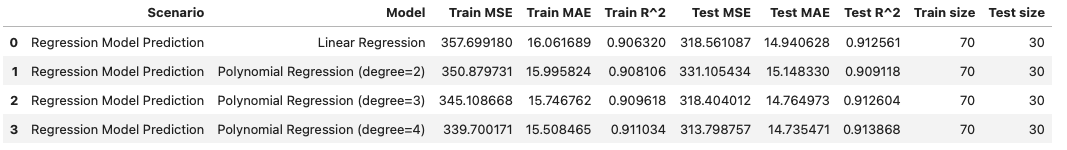

## 1.5 Discussion and interpretation

### 1) Which model performs best on the test set and why?

Based on the **test metrics** *(lower MSE/MAE is better; higher \(R^2\) is better)*, the **Polynomial Regression (degree = 4)** model performs best:

- **Poly (deg = 4):** Test MSE = **313.7988**, Test MAE = **14.7355**, Test \(R^2\) = **0.913868**
- **Linear Regression:** Test MSE = **318.5611**, Test MAE = **14.9406**, Test \(R^2\) = **0.912561**

Therefore, **deg = 4** has the **lowest test error** and the **highest test \(R^2\)** among the models reported.

### 2) Does increasing polynomial degree always improve performance? If not, explain what you observe
Based on the **test metrics**, increasing polynomial degree generally improves training performance, but test performance does not improve at every step:
- Training MSE decreases as degree increases: Linear: 357.6992 → deg2: 350.8797 → deg3: 345.1087 → deg4: 339.7002
- However, the test MSE does not strictly decrease: Linear: 318.5611, deg2: 331.1054 (worse), deg3: 318.4040 (about the same as linear), deg4: 313.7988 (best)
- Therefore, it doesn't always improve performance.

### 3) If a model performs unexpectedly poorly ropose at least two plausible reasons
- A clear example is Poly (deg=2), which has better training metrics than Linear but worse test metrics:
- Train MSE: 350.8797 (better than Linear’s 357.6992)
- Test MSE: 331.1054 (worse than Linear’s 318.5611)
- Two plausible reasons:
 1. Overfitting / higher variance:
Degree 2 fits the training set slightly better but generalizes worse (test error increases), which is consistent with the model picking up patterns that don’t carry over to unseen data.
 2. Noise / outliers + limited feature information:
Predicting Horse Power using only one feature (Fuel Economy MPG). If the relationship is noisy (e.g., different car weights/engines cause different HP even at the same MPG), extra polynomial terms can amplify noise and hurt test performance.


In [12]:

# ============================================================
# Load dataset
# ============================================================

NEW_DATA_PATH = "electricity_consumption_based_weather_dataset.csv"
new_df = pd.read_csv(NEW_DATA_PATH)

print("Shape:", new_df.shape)
print("\nColumns:")
print(new_df.columns.tolist())

display(new_df.head())

print("\nSummary statistics:")
display(new_df.describe(include="all"))

print("\nMissing values per column:")
display(new_df.isna().sum())


Shape: (1433, 6)

Columns:
['date', 'AWND', 'PRCP', 'TMAX', 'TMIN', 'daily_consumption']


,date,AWND,PRCP,TMAX,TMIN,daily_consumption
0,2006-12-16,2.5,0.0,10.6,5.0,1209.176
1,2006-12-17,2.6,0.0,13.3,5.6,3390.460
2,2006-12-18,2.4,0.0,15.0,6.7,2203.826
3,2006-12-19,2.4,0.0,7.2,2.2,1666.194
4,2006-12-20,2.4,0.0,7.2,1.1,2225.748



Summary statistics:


,date,AWND,PRCP,TMAX,TMIN,daily_consumption
count,1433,1418.000000,1433.000000,1433.000000,1433.000000,1433.000000
unique,1433,NaN,NaN,NaN,NaN,NaN
top,2006-12-16,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.642313,3.800488,17.187509,9.141242,1561.078061
std,NaN,1.140021,10.973436,10.136415,9.028417,606.819667
min,NaN,0.000000,0.000000,-8.900000,-14.400000,14.218000
25%,NaN,1.800000,0.000000,8.900000,2.200000,1165.700000
50%,NaN,2.400000,0.000000,17.800000,9.400000,1542.650000
75%,NaN,3.300000,1.300000,26.100000,17.200000,1893.608000



Missing values per column:


date                  0
AWND                 15
PRCP                  0
TMAX                  0
TMIN                  0
daily_consumption     0
dtype: int64

Based on the summary statistics: the dependent variable is **daily_consumption**
And there are 15 missing values in the AWND column

In [9]:
# Define some helper functions for ML
TARGET_COL = "daily_consumption"

# Split the data into 70/30 sets
def split_data(X, y, test_size, random_state):
    """70/30 random train-test split."""
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

# Calculate the metrics for evaluation
def compute_metrics(y_true, y_pred):
    """Return MSE, MAE, R^2."""
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R^2": r2_score(y_true, y_pred),
    }

# Prepare the dataset for training
def prepare_xy(df_in, target_col=TARGET_COL):
    """Drop missing rows, split into X and y."""
    df_clean = df_in.dropna().copy()
    X = df_clean.drop(columns=[target_col,'date'])
    y = df_clean[target_col]
    return X, y

def print_fitted_equation(model, input_feature_names, target_name=TARGET_COL, top_k_terms=15):
    """Print a readable fitted equation.

    For polynomial models, the number of terms can become very large,
    so we print only the TOP-K terms by absolute coefficient magnitude.
    """
    intercept, coefs, feat_names = _get_linear_parts(model, input_feature_names)

    # Sort by absolute coefficient magnitude
    order = np.argsort(np.abs(coefs))[::-1]
    order = order[:min(top_k_terms, len(coefs))]

    terms = []
    for idx in order:
        terms.append(f"({coefs[idx]:+.4f}) * {feat_names[idx]}")

    eq = f"{target_name} = {intercept:.4f} " + " ".join(terms)

    print("\n--- Fitted Model Equation (Top Terms) ---")
    print(eq)
    if len(coefs) > top_k_terms:
        print(f"(Showing top {top_k_terms} terms out of {len(coefs)} total terms.)")


def _get_linear_parts(model, input_feature_names):
    """Extract (intercept, coefficients, feature_names) from either:
       - LinearRegression
       - Pipeline(PolynomialFeatures -> LinearRegression)
    """
    # Plain LinearRegression
    if isinstance(model, LinearRegression):
        intercept = float(model.intercept_)
        coefs = np.array(model.coef_).ravel()
        feat_names = np.array(list(input_feature_names))
        return intercept, coefs, feat_names

    # Polynomial pipeline
    if hasattr(model, "named_steps") and "poly" in model.named_steps and "lr" in model.named_steps:
        poly = model.named_steps["poly"]
        lr = model.named_steps["lr"]

        feat_names = poly.get_feature_names_out(input_features=list(input_feature_names))
        intercept = float(lr.intercept_)
        coefs = np.array(lr.coef_).ravel()
        return intercept, coefs, np.array(feat_names)

    raise ValueError("Unsupported model type for equation printing.")




def run_models_and_evaluate(df_in, scenario_name, degrees=(1, 2, 3, 4),
                            target_col=TARGET_COL, test_size=0.30, random_state=42,
                            show_equation=True, top_k_terms=15):
    """Train/evaluate linear (deg=1) + polynomial regression models.

    Returns a DataFrame of metrics.
    Also prints fitted equations and scatter plots (test set) for each model.
    """
    X, y = prepare_xy(df_in, target_col=target_col)
    X_train, X_test, y_train, y_test = split_data(X, y, test_size=test_size, random_state=random_state)

    rows = []

    for deg in degrees:
        if deg == 1:
            model = LinearRegression()
            model_name = "Linear Regression"
        else:
            model = Pipeline([
                ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
                ("lr", LinearRegression())
            ])
            model_name = f"Polynomial Regression (degree={deg})"

        # Fit model
        model.fit(X_train, y_train)

        # Predict
        yhat_train = model.predict(X_train)
        yhat_test  = model.predict(X_test)

        # Metrics
        train_m = compute_metrics(y_train, yhat_train)
        test_m  = compute_metrics(y_test, yhat_test)

        # Report equation + plot (TEST set)
        print("\n============================================================")
        print(f"Scenario: {scenario_name}")
        print(f"Model: {model_name}")
        print("============================================================")

        if show_equation:
            print_fitted_equation(
                model=model,
                input_feature_names=X_train.columns,
                target_name=target_col,
                top_k_terms=top_k_terms
            )


        rows.append({
            "Scenario": scenario_name,
            "Model": model_name,
            "Train MSE": train_m["MSE"],
            "Train MAE": train_m["MAE"],
            "Train R^2": train_m["R^2"],
            "Test MSE": test_m["MSE"],
            "Test MAE": test_m["MAE"],
            "Test R^2": test_m["R^2"],
            "Train size": len(X_train),
            "Test size": len(X_test),
        })

    return pd.DataFrame(rows)


In [10]:
results_B = run_models_and_evaluate(
    new_df,
    scenario_name="Regression Model Prediction for Task 2",
    degrees=(1, 2, 3, 4),
    show_equation=True,
    top_k_terms=15
)

display(results_B)


Scenario: Regression Model Prediction for Task 2
Model: Linear Regression

--- Fitted Model Equation (Top Terms) ---
daily_consumption = 2045.7562 (-17.2734) * TMAX (-17.0839) * TMIN (-7.5783) * AWND (-3.3603) * PRCP

Scenario: Regression Model Prediction for Task 2
Model: Polynomial Regression (degree=2)

--- Fitted Model Equation (Top Terms) ---
daily_consumption = 2037.4142 (+165.5267) * AWND (-60.9740) * TMAX (-27.8962) * AWND^2 (+26.8325) * TMIN (-10.4820) * PRCP (-2.6130) * TMAX TMIN (-1.9368) * PRCP TMIN (+1.8505) * TMAX^2 (+1.5725) * PRCP TMAX (+1.2309) * AWND PRCP (+1.1693) * AWND TMIN (-1.0760) * AWND TMAX (+0.2939) * TMIN^2 (-0.0545) * PRCP^2

Scenario: Regression Model Prediction for Task 2
Model: Polynomial Regression (degree=3)

--- Fitted Model Equation (Top Terms) ---
daily_consumption = 1405.7630 (+509.9634) * AWND (-140.8094) * AWND^2 (+67.4216) * TMAX (-63.7983) * TMIN (+25.0565) * TMAX TMIN (-20.2281) * AWND TMIN (-13.9648) * TMIN^2 (-13.1044) * TMAX^2 (+9.3010) * 

,Scenario,Model,Train MSE,Train MAE,Train R^2,Test MSE,Test MAE,Test R^2,Train size,Test size
0,Regression Model Prediction for Task 2,Linear Regression,272403.396174,384.465016,0.276000,2.481258e+05,375.404537,0.299333,992,426
1,Regression Model Prediction for Task 2,Polynomial Regression (degree=2),264765.769932,379.648753,0.296300,2.552685e+05,379.039083,0.279163,992,426
2,Regression Model Prediction for Task 2,Polynomial Regression (degree=3),259249.534870,375.952901,0.310961,2.656237e+05,385.235167,0.249922,992,426
3,Regression Model Prediction for Task 2,Polynomial Regression (degree=4),251909.339001,372.116566,0.330470,1.215149e+07,578.642201,-33.313844,992,426


Here are the results for the model evaluation after dropping the null data and the date value:
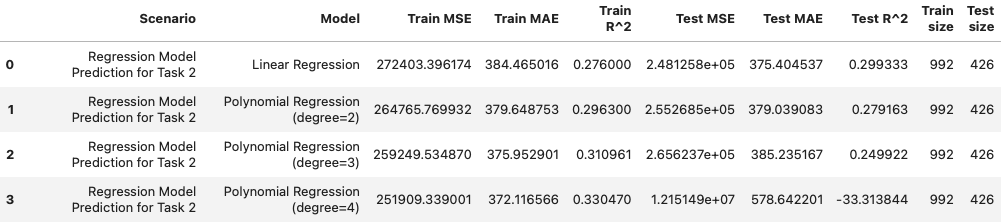

## 2.5 Discussion and interpretation

### 1) Which model performs best on the test set and why?

Based on the **test metrics** *(lower MSE/MAE is better; higher \(R^2\) is better)*, the **Linear Regression (degree = 1)** model performs best:

- **Linear Regression:** Test MSE = **2.48*10^5**, Test MAE = **375.405**, Test \(R^2\) = **0.299**

Interpretation: weather features do have predictive signal, but the relationship your model can capture from the available features appears mostly linear. Therefore, weather data alone is not sufficient to predict electricity usage.

### 2) Do polynomial models improve the fit compared to linear regression? If yes, why might electricity consumption have nonlinear dependence on weather?
Based on the **test metrics**, increasing polynomial degree only improves training fit(on training set only) slightly but do not improve test performance.
- Training MSE decreases as degree increases: Linear: 272,403 → deg2: 264,766 → deg3: 259,250 → deg4: 251,909
- Train R^2 increases: 0.276 → 0.296 → 0.311 → 0.330
- However, the test MSE increases: 2.481 * 10^5 → 2.553 * 10^5 → 2.656 * 10^5 → 1.215 * 10^7
- Plynomial terms add complexity that helps the model to fit the data more but that may cause overfitting. Also humidity + temperature interactions may cause nonlinear dependence because hot + humid can drive more AC than hot + dry, creating interaction-based nonlinearities. Other reasons like lag/thermal inertia: Buildings respond with delay—today’s usage may depend on yesterday’s temperature/solar load, producing nonlinear dynamics.

### 3) If higher-degree models perform worse on the test set, explain this behavior using evidence from
metrics (e.g., train error decreases but test error increases).
- Training MSE decreases as degree increases: Linear: 272,403 → deg2: 264,766 → deg3: 259,250 → deg4: 251,909
- Test MSE increases as degree increases:  2.481 * 10^5 → 2.553 * 10^5 → 2.656 * 10^5 → 1.215 * 10^7
-  Train R^2 increases: 0.276 → 0.296 → 0.311 → 0.330
-  However the test R^2 decreases from 0.299 to 0.279, 0.249 and even goes to -33 for polynomial regression of degree of 4.
-  Negative R^2 being this large means the model is far worse than predicting the test mean, which often happens when high-degree polynomial features create unstable coefficients
### 4) If none of the models achieve good test performance, provide at least two reasons supported by your outputs 
##### 1) Limited feature set (weather alone can’t explain most demand)
- **Evidence:** even the best model explains only ~**30%** of variance (**Test \(R^2 \approx 0.299\)**), meaning ~**70%** of the variability is left unexplained.  
- Real electricity usage depends heavily on **occupancy, appliance usage, schedules, building size/insulation, thermostat settings**, etc. If those drivers aren’t included as input features, the model cannot learn them.
##### 2) Unmodeled time/season structure and regime changes
- **Evidence:** adding polynomial complexity improves training fit (Train \(R^2\) rises from **0.276 → 0.330**) but test fit drops (**0.299 → 0.279 → 0.250**), suggesting the model is learning patterns that do not generalize.  
- This often happens when demand has strong **seasonality, day-of-week effects, holidays, and heating vs. cooling “modes.”** Without time-based features (month, weekday, holiday) or HVAC regime indicators (e.g., heating/cooling degree days), the mapping from weather → usage can look inconsistent.
##### 3) Overfitting/instability from polynomial expansion (especially degree 4)
- **Evidence:** degree-4 has **Train MSE \(\approx 2.52\times 10^5\)** but **Test MSE \(\approx 1.22\times 10^7\)** and **Test \(R^2 \approx -33.3\)**, far worse than predicting the mean.  
- This indicates polynomial features can create **unstable coefficients** (multicollinearity, sensitivity), causing the model to fit training quirks rather than true signal.

